## Task 2

**Choice of dataset**: [Kaggle: ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat)

Each row represents ONE segmented heartbeat from a patient. Every row contains exactly 188 columns.

**Columns 1 through 187**: These are the sequential electrical voltage readings of the heartbeat over time.

**Column 188**: This is the target label (0 = Normal, 1 = Supraventricular premature beat, 2 = Premature ventricular contraction, 3 = Fusion of ventricular and normal beat, 4 = Unclassifiable beat).

Standard models look at all data points at once and don't care about the order. If you scrambled the columns, a standard model wouldn't know the difference.

But a heartbeat is a continuous wave. To spot an irregular heartbeat, the model needs to understand the shape and timing of that wave. A sequence model reads the data exactly how a doctor reads an ECG chart—left to right.


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

#### EDA

In [71]:
df = pd.read_csv('mitbih_train.csv', header=None)

In [72]:
class_names = {
    0.0: 'Normal Beat',
    1.0: 'Supraventricular Premature',
    2.0: 'Premature Ventricular',
    3.0: 'Fusion Beat',
    4.0: 'Unclassifiable'
}

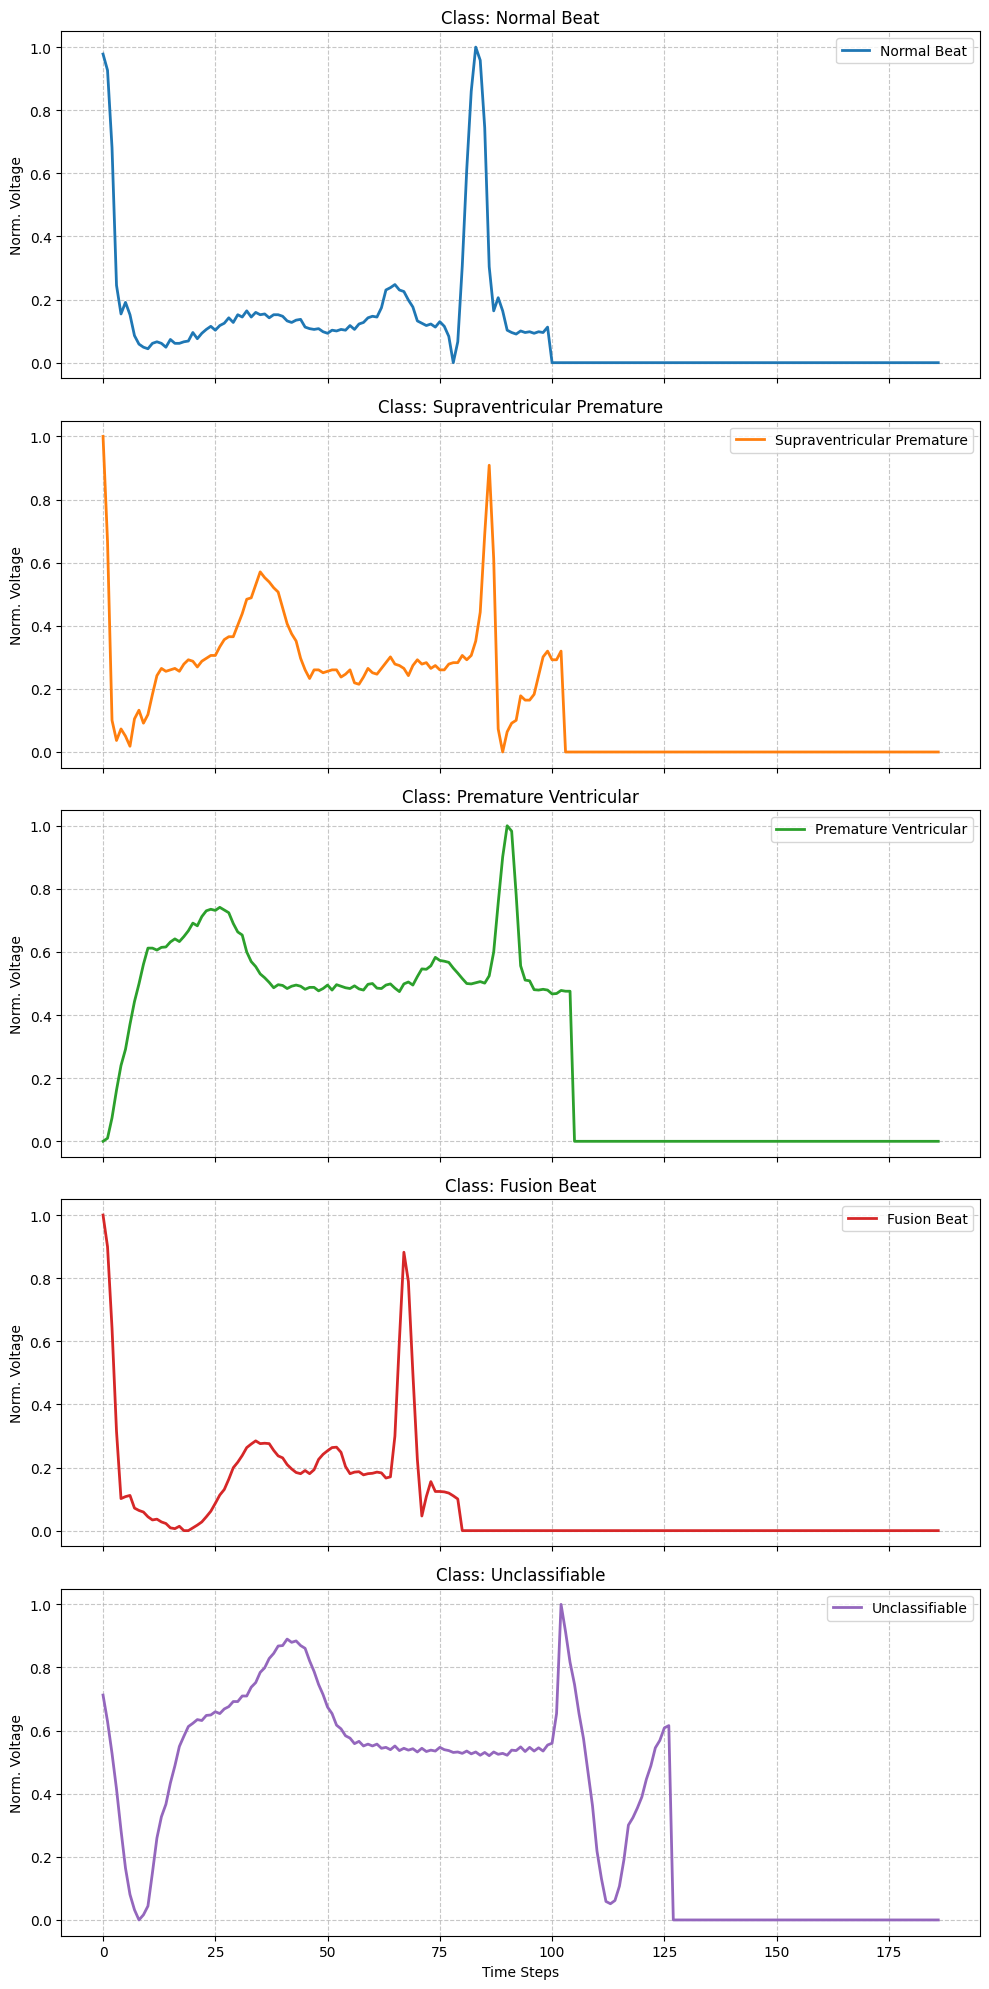

In [73]:
fig, axes = plt.subplots(5, 1, figsize=(10, 20), sharex=True)

for i, (class_val, class_name) in enumerate(class_names.items()):
    # Get the first sample belonging to the current class
    sample = df[df[187] == class_val].iloc[0, :187] 
    
    # Plot on the specific subplot axis
    axes[i].plot(sample, label=class_name, color=f'C{i}', linewidth=2)
    
    axes[i].set_title(f'Class: {class_name}')
    axes[i].set_ylabel('Norm. Voltage')
    axes[i].grid(True, linestyle='--', alpha=0.7)
    axes[i].legend(loc='upper right')

plt.xlabel('Time Steps')
plt.tight_layout()
plt.show()

In [74]:
# 1. Check Scaling
features = df.iloc[:, :-1].values # all columns except label
print(f"Dataset Global Minimum: {features.min():.4f}")
print(f"Dataset Global Maximum: {features.max():.4f}")

Dataset Global Minimum: 0.0000
Dataset Global Maximum: 1.0000


In [75]:
# Check label distribution
class_counts = df[187].value_counts().sort_index()
for class_val, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Class {int(class_val)} ({class_names[class_val]}): {count} samples ({percentage:.2f}%)")

Class 0 (Normal Beat): 72471 samples (82.77%)
Class 1 (Supraventricular Premature): 2223 samples (2.54%)
Class 2 (Premature Ventricular): 5788 samples (6.61%)
Class 3 (Fusion Beat): 641 samples (0.73%)
Class 4 (Unclassifiable): 6431 samples (7.35%)


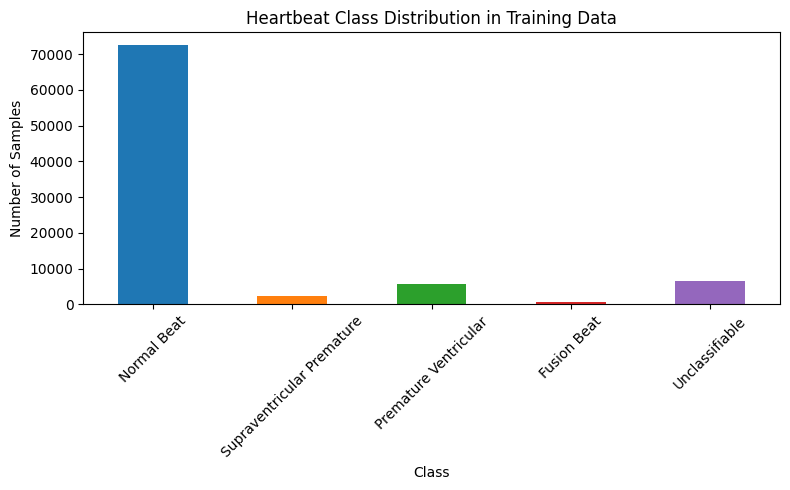

In [76]:
plt.figure(figsize=(8, 5))
class_counts.plot(kind='bar', color=['C0', 'C1', 'C2', 'C3', 'C4'])
plt.title('Heartbeat Class Distribution in Training Data')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(ticks=range(5), labels=[class_names[i] for i in range(5)], rotation=45)
plt.tight_layout()
plt.show()

There is a big class imbalance, which we will fix by balancing the loss function (penalizing wrong prediction on the smaller labels)

In [77]:
import torch
import torch.nn as nn
import numpy as np
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

In [78]:
# Hyperparameters
BATCH_SIZE = 64
NUM_FEATURES = 1
HIDDEN_SIZE = 32     
NUM_LAYERS = 1
NUM_CLASSES = 5      
EPOCHS = 20
LEARNING_RATE = 0.0001

In [79]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [80]:
def load_data(csv_file):
    print(f"Loading data from {csv_file}")
    data = pd.read_csv(csv_file, header=None).values
    
    # Split into Features (X) and Labels (y)
    X = data[:, :-1].astype(np.float32) # take all columns except the last
    y = data[:, -1].astype(np.int64)    # only take the last column
    X_tensor = torch.tensor(X)
    y_tensor = torch.tensor(y)
    
    # Reshape from (Samples, 187) to (Samples, 187, 1)
    X_tensor = X_tensor.unsqueeze(-1)
    
    return TensorDataset(X_tensor, y_tensor)

In [81]:
def get_gradient_norm(model):
    # Track gradient to prove they are vanishing or not
    total_norm = 0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2) # Calculate the L2 norm
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5

In [82]:
def train_model(model, criterion, train_loader, val_loader, optimizer, epochs):
    train_losses, val_losses = [], []
    grad_norm_history = []

    print("Training phase")
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        # Training
        for batches, labels in train_loader:
            batches, labels = batches.to(device), labels.to(device)
            optimizer.zero_grad()
            # Forward Pass
            outputs = model(batches)
            # Compute Loss
            loss = criterion(outputs, labels)
            # Backward Pass (Compute Gradients)
            loss.backward()
            # track gradients
            grad_norm = get_gradient_norm(model)
            grad_norm_history.append(grad_norm)
            # Update weights
            optimizer.step()
            running_train_loss += loss.item()
            
        avg_train_loss = running_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # VALIDATION
        model.eval()
        running_val_loss = 0.0
        all_val_preds, all_val_labels = [], []
        
        with torch.no_grad():
            for batches, labels in val_loader:
                batches, labels = batches.to(device), labels.to(device)
                
                outputs = model(batches)
                loss = criterion(outputs, labels)
                running_val_loss += loss.item()
                
                # Get the predicted class (the one with the highest logit score)
                _, predicted = torch.max(outputs.data, 1)
                
                all_val_preds.extend(predicted.cpu().numpy())
                all_val_labels.extend(labels.cpu().numpy())
                
        avg_val_loss = running_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        # Calculate our defined metric: Macro F1-Score
        val_f1 = f1_score(all_val_labels, all_val_preds, average='macro')
        
        print(f"Epoch {epoch+1}: Train Loss: {avg_train_loss:.4f} ; Val Loss: {avg_val_loss:.4f} ; Val Macro F1: {val_f1:.4f}")
    return train_losses, val_losses, grad_norm_history

In [83]:
full_train_dataset = load_data('mitbih_train.csv')
test_dataset = load_data('mitbih_test.csv')

Loading data from mitbih_train.csv


Loading data from mitbih_test.csv


In [84]:
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, (train_size, val_size))

In [85]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [86]:
print("Making sure the shapes match")

# Grab exactly one batch from the training data
sample_seqs, _ = next(iter(train_loader))

# Expected: (Batch Size, 187 Timesteps, 1 Feature)
(BATCH_SIZE, 187, NUM_FEATURES)

Making sure the shapes match


(64, 187, 1)

In [87]:
y_train = df[187].values
class_weights = compute_class_weight(
        class_weight='balanced', 
        classes=np.unique(y_train), 
        y=y_train
    )

In [88]:
tensor_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
tensor_weights

tensor([ 0.2416,  7.8771,  3.0254, 27.3179,  2.7229], device='cuda:0')

In [89]:
class ECG_RNN(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_RNN, self).__init__()
        
        # hidden size doesn't need to match the number of timesteps.
        # it means that at every single timestep, the RNN maintains a list of exactly hidden_size numbers.
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # The RNN Layer
        # batch_first=True means the input tensor is shaped (batch_size, Timesteps, Features), but the features is just 1 since we recorded only Voltage.
        
        # ACTIVATION FUNCTION: By default, PyTorch's nn.RNN uses tanh at each time step to compute the hidden state. 
        # This non-linearity squashes internal values between -1 and 1, which helps prevent exploding gradients 
        # as the model multiplies weights across all 187 time steps.
        self.rnn = nn.RNN(num_features, hidden_size, num_layers, batch_first=True)
        
        # The Output Layer
        # This converts the 1D tensor of the RNN hidden layer output into raw logits.
        # (Note: Softmax is applied automatically later by the CrossEntropyLoss function).
        self.output = nn.Linear(hidden_size, num_classes)        
    def forward(self, x):
        # Initialize the hidden state with zeros
        # Shape: (num_layers, batch_size, hidden_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate through the RNN
        # out shape: (batch_size, Timesteps, hidden_size)
        out, _ = self.rnn(x, h0)
        
        # Keep all batches and hidden numbers, but only look at the last timestep to use for prediction.
        final_out = out[:, -1, :] 
        
        # Pass the final hidden state to the fully connected layer
        # Output shape: (batch_size, num_classes)
        
        return self.output(final_out) 

In [94]:
class ECG_LSTM(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_LSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(num_features, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        # LSTM requires BOTH a hidden state (h0) and a cell state (c0)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.lstm(x, (h0, c0))
        final_out = out[:, -1, :] 
        return self.output(final_out)

In [99]:
class ECG_GRU(nn.Module):
    def __init__(self, num_features, hidden_size, num_layers, num_classes):
        super(ECG_GRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # Using nn.GRU. It combines the forget and input gates into a single "update gate"
        self.gru = nn.GRU(num_features, hidden_size, num_layers, batch_first=True)
        self.output = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        out, _ = self.gru(x, h0)
        final_out = out[:, -1, :] 
        return self.output(final_out)

In [90]:
# Initialize RNN Model, Loss, and Optimizer
model_rnn = ECG_RNN(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss(weight=tensor_weights)
optimizer_rnn = optim.Adam(model_rnn.parameters(), lr=LEARNING_RATE)

In [91]:
train_losses_rnn, val_losses_rnn, grad_norm_history_rnn = train_model(model_rnn, criterion, train_loader, val_loader, optimizer_rnn, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6017 ; Val Loss: 1.5973 ; Val Macro F1: 0.1812
Epoch 2: Train Loss: 1.5991 ; Val Loss: 1.5951 ; Val Macro F1: 0.2042
Epoch 3: Train Loss: 1.5894 ; Val Loss: 1.5851 ; Val Macro F1: 0.1329
Epoch 4: Train Loss: 1.5720 ; Val Loss: 1.5727 ; Val Macro F1: 0.0828
Epoch 5: Train Loss: 1.5619 ; Val Loss: 1.5556 ; Val Macro F1: 0.1130
Epoch 6: Train Loss: 1.5557 ; Val Loss: 1.5572 ; Val Macro F1: 0.0843
Epoch 7: Train Loss: 1.5508 ; Val Loss: 1.5481 ; Val Macro F1: 0.0740
Epoch 8: Train Loss: 1.5443 ; Val Loss: 1.5422 ; Val Macro F1: 0.0792
Epoch 9: Train Loss: 1.5422 ; Val Loss: 1.5374 ; Val Macro F1: 0.0873
Epoch 10: Train Loss: 1.5409 ; Val Loss: 1.5358 ; Val Macro F1: 0.0829
Epoch 11: Train Loss: 1.5418 ; Val Loss: 1.5339 ; Val Macro F1: 0.0954
Epoch 12: Train Loss: 1.5363 ; Val Loss: 1.5358 ; Val Macro F1: 0.0833
Epoch 13: Train Loss: 1.5390 ; Val Loss: 1.5302 ; Val Macro F1: 0.0874
Epoch 14: Train Loss: 1.5347 ; Val Loss: 1.5313 ; Val Macro F1: 0.0971


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.1220


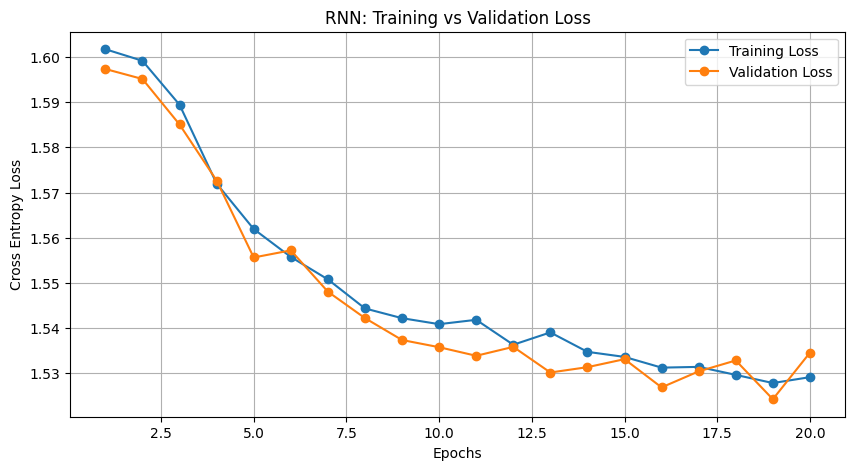

In [92]:
print("Testing Phase")
model_rnn.eval()
all_test_preds_rnn, all_test_labels_rnn = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_rnn(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_rnn.extend(predicted.cpu().numpy())
        all_test_labels_rnn.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_rnn, all_test_preds_rnn, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_rnn, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_rnn, label='Validation Loss', marker='o')
plt.title('RNN: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

The Macro F1-score for the basic RNN seems to be very low.

This can be due to the vanishing gradient problem since we have 187 time steps. The repeated multiplication of weights through the standard tanh activation causes the learning gradients to shrink to near zero.

Plus, as we can see, the training and validation loss seem to converge around 1.53, and they didn't decrease much from the initial 1.60.


Without the ability to remember the full temporal structure of the heartbeat, the model fails to differentiate between imbalanced classes.

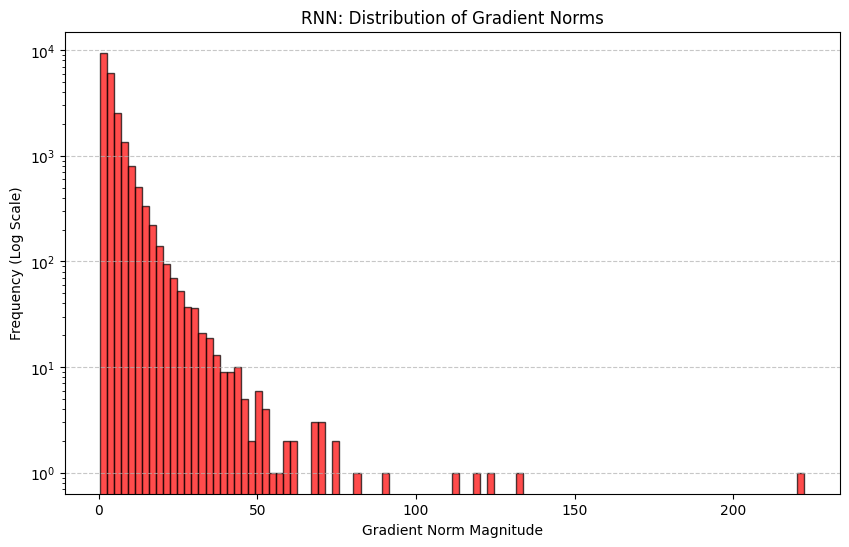

In [93]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_rnn, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('RNN: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [95]:
# Initialize LSTM Model, Loss, and Optimizer
model_lstm = ECG_LSTM(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
optimizer_lstm = optim.Adam(model_lstm.parameters(), lr=LEARNING_RATE)

In [96]:
train_losses_lstm, val_losses_lstm, grad_norm_history_lstm = train_model(model_lstm, criterion, train_loader, val_loader, optimizer_lstm, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6077 ; Val Loss: 1.5992 ; Val Macro F1: 0.1812
Epoch 2: Train Loss: 1.5990 ; Val Loss: 1.5869 ; Val Macro F1: 0.2145
Epoch 3: Train Loss: 1.5739 ; Val Loss: 1.5613 ; Val Macro F1: 0.2055
Epoch 4: Train Loss: 1.5524 ; Val Loss: 1.5425 ; Val Macro F1: 0.0796
Epoch 5: Train Loss: 1.5663 ; Val Loss: 1.5586 ; Val Macro F1: 0.2344
Epoch 6: Train Loss: 1.5372 ; Val Loss: 1.5311 ; Val Macro F1: 0.0882
Epoch 7: Train Loss: 1.5252 ; Val Loss: 1.5262 ; Val Macro F1: 0.0812
Epoch 8: Train Loss: 1.5161 ; Val Loss: 1.4880 ; Val Macro F1: 0.0903
Epoch 9: Train Loss: 1.5272 ; Val Loss: 1.4738 ; Val Macro F1: 0.0855
Epoch 10: Train Loss: 1.5190 ; Val Loss: 1.4539 ; Val Macro F1: 0.2344
Epoch 11: Train Loss: 1.5859 ; Val Loss: 1.5025 ; Val Macro F1: 0.1791
Epoch 12: Train Loss: 1.4552 ; Val Loss: 1.4213 ; Val Macro F1: 0.2469
Epoch 13: Train Loss: 1.4100 ; Val Loss: 1.3922 ; Val Macro F1: 0.2517
Epoch 14: Train Loss: 1.3586 ; Val Loss: 1.3391 ; Val Macro F1: 0.2790


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.2194


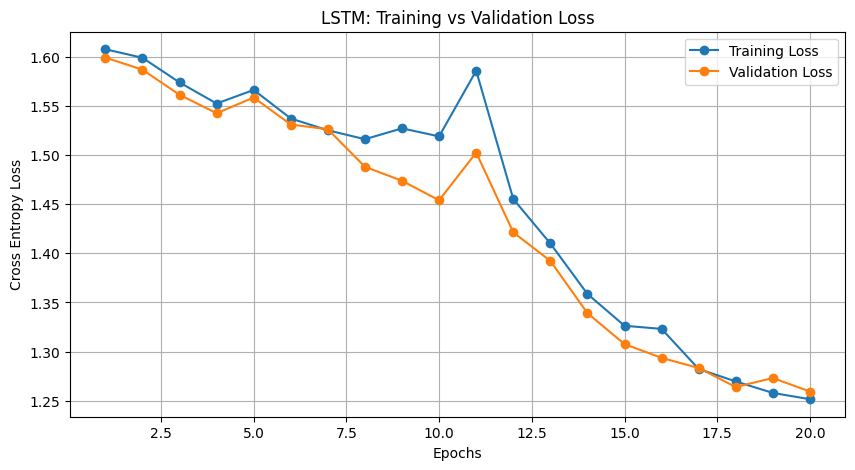

In [97]:
print("Testing Phase")
model_lstm.eval()
all_test_preds_lstm, all_test_labels_lstm = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_lstm(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_lstm.extend(predicted.cpu().numpy())
        all_test_labels_lstm.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_lstm, all_test_preds_lstm, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_lstm, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_lstm, label='Validation Loss', marker='o')
plt.title('LSTM: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

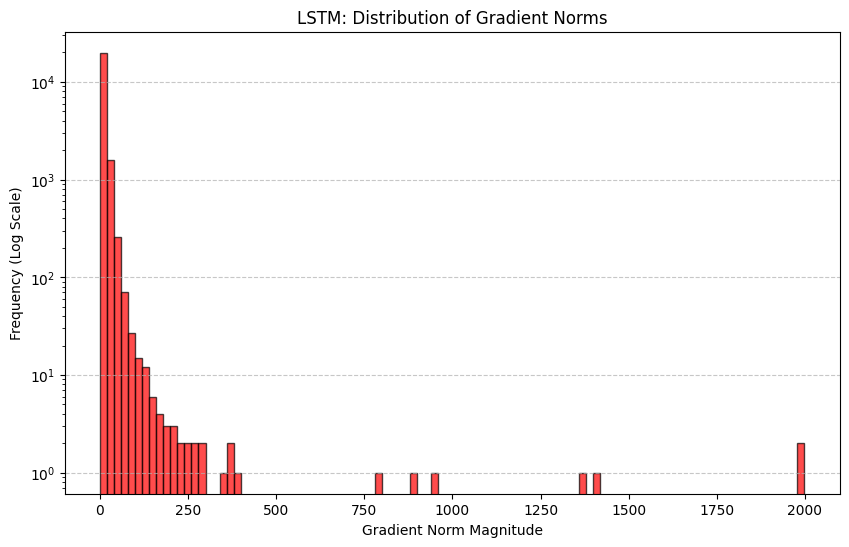

In [98]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_lstm, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('LSTM: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [100]:
model_gru = ECG_GRU(NUM_FEATURES, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES).to(device)
optimizer_gru = optim.Adam(model_gru.parameters(), lr=LEARNING_RATE)

In [101]:
train_losses_gru, val_losses_gru, grad_norm_history_gru = train_model(model_gru, criterion, train_loader, val_loader, optimizer_gru, EPOCHS)

Training phase
Epoch 1: Train Loss: 1.6076 ; Val Loss: 1.5975 ; Val Macro F1: 0.1812
Epoch 2: Train Loss: 1.5985 ; Val Loss: 1.5948 ; Val Macro F1: 0.1830
Epoch 3: Train Loss: 1.5970 ; Val Loss: 1.5933 ; Val Macro F1: 0.2150
Epoch 4: Train Loss: 1.5938 ; Val Loss: 1.5883 ; Val Macro F1: 0.2167
Epoch 5: Train Loss: 1.5799 ; Val Loss: 1.5634 ; Val Macro F1: 0.1022
Epoch 6: Train Loss: 1.5423 ; Val Loss: 1.5099 ; Val Macro F1: 0.0580
Epoch 7: Train Loss: 1.4246 ; Val Loss: 1.4304 ; Val Macro F1: 0.1614
Epoch 8: Train Loss: 1.3778 ; Val Loss: 1.3757 ; Val Macro F1: 0.1661
Epoch 9: Train Loss: 1.3611 ; Val Loss: 1.3750 ; Val Macro F1: 0.1781
Epoch 10: Train Loss: 1.3547 ; Val Loss: 1.3621 ; Val Macro F1: 0.1860
Epoch 11: Train Loss: 1.3452 ; Val Loss: 1.3500 ; Val Macro F1: 0.1813
Epoch 12: Train Loss: 1.3386 ; Val Loss: 1.3469 ; Val Macro F1: 0.2015
Epoch 13: Train Loss: 1.3332 ; Val Loss: 1.3319 ; Val Macro F1: 0.2175
Epoch 14: Train Loss: 1.3196 ; Val Loss: 1.3214 ; Val Macro F1: 0.2377


Testing Phase
FINAL TEST MACRO F1-SCORE: 0.2669


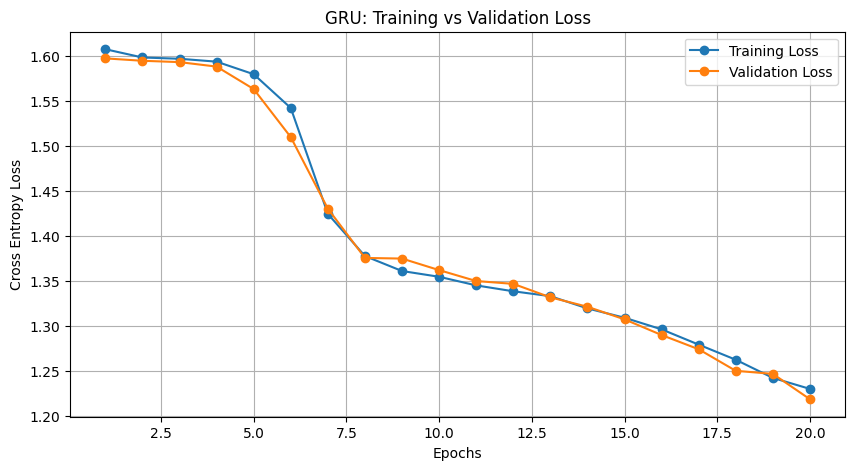

In [102]:
print("Testing Phase")
model_gru.eval()
all_test_preds_gru, all_test_labels_gru = [], []
with torch.no_grad():
    for batches, labels in test_loader:
        batches, labels = batches.to(device), labels.to(device)
        outputs = model_gru(batches)
        _, predicted = torch.max(outputs.data, 1)
        all_test_preds_gru.extend(predicted.cpu().numpy())
        all_test_labels_gru.extend(labels.cpu().numpy())

test_f1 = f1_score(all_test_labels_gru, all_test_preds_gru, average='macro')
print(f"FINAL TEST MACRO F1-SCORE: {test_f1:.4f}")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(range(1, EPOCHS+1), train_losses_gru, label='Training Loss', marker='o')
plt.plot(range(1, EPOCHS+1), val_losses_gru, label='Validation Loss', marker='o')
plt.title('GRU: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Cross Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

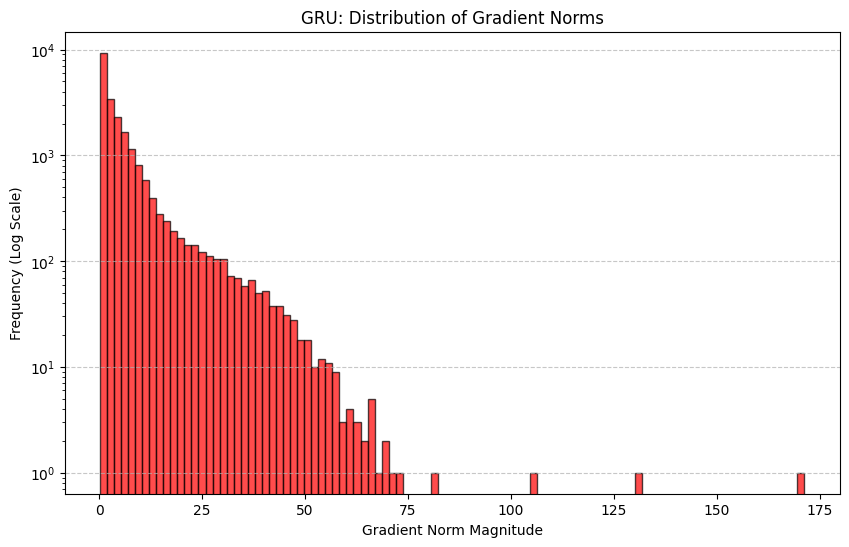

In [104]:
plt.figure(figsize=(10, 6))
plt.hist(grad_norm_history_gru, bins=100, color='red', alpha=0.7, edgecolor='black')
plt.yscale('log') 
plt.title('GRU: Distribution of Gradient Norms')
plt.xlabel('Gradient Norm Magnitude')
plt.ylabel('Frequency (Log Scale)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Overall, we can see the LSTM and the GRU are performing better than the RNN.

The training loss and validation loss seem to be both decreasing gradually till 1.20, which is lower than the RNN.

The LSTM and the GRU also yielded a higher F1 macro score.

In the histogram of the gradient norms, we can see the maximum gradient magnitude of the RNN rarely exceeded 200. In contrast, the LSTM allowed for much larger weight updates. The LSTM is suffering less from the vanishing gradient problem.

However, the LSTM and the GRU are still underfitting. It seems 187 steps is still a long sequence for a single layer network.

Plus, since the Macro F1 metric averages the score of all 5 classes equally, failing on just one rare class (e.g., class 3 which makes up 0.73% of the data) tanks the entire score.